In [ ]:
!ls -lh "/content/archive (3).zip"

-rw-r--r-- 1 root root 73M Aug 28 15:15 '/content/archive (3).zip'


In [ ]:
!file "/content/archive (3).zip"

/content/archive (3).zip: Zip archive data, at least v4.5 to extract, compression method=deflate


In [ ]:
!unzip -q "/content/archive (3).zip" -d "/content/PlantVillage"

[/content/archive (3).zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/archive (3).zip or
        /content/archive (3).zip.zip, and cannot find /content/archive (3).zip.ZIP, period.


In [ ]:
!rm "/content/archive (3).zip"

In [ ]:
import os

files = os.listdir("/content")

print(files)

['.config', 'archive (3).zip', 'sample_data']


In [ ]:
!file "/content/archive (3).zip"
!unzip -t "/content/archive (3).zip" | tail -5

/content/archive (3).zip: data
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/archive (3).zip or
        /content/archive (3).zip.zip, and cannot find /content/archive (3).zip.ZIP, period.
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/archive (3).zip or
        /content/archive (3).zip.zip, and cannot find /content/archive (3).zip.ZIP, period.


In [ ]:
!rm "/content/archive (3).zip"

In [ ]:
!pip install -q kaggle

In [ ]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_2f4bf7b2de11fe578452b8f994949e63"

In [ ]:
!kaggle datasets list -s plantvillage

ref                                                       title                                              size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------  -------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
abdallahalidev/plantvillage-dataset                       PlantVillage Dataset                         4371949460  2019-09-01 11:52:26.883000         123195       1068  0.875            
emmarex/plantdisease                                      PlantVillage Dataset                          689512690  2018-10-30 01:16:23.440000         175495       1247  0.5625           
mohitsingh1804/plantvillage                               PlantVillage                                  857351099  2021-08-20 01:08:58.493000          18501        113  0.625            
soumiknafiul/plantvillage-dataset-labeled                 PlantVi

In [ ]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset -p /content

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:22<00:00, 95.8MB/s]



In [ ]:
import zipfile
import os

zip_path = "/content/plantvillage-dataset.zip"
extract_path = "/content/PlantVillage"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

print(os.listdir("/content/PlantVillage"))

['plantvillage dataset']


In [ ]:
import os

dataset_path = "/content/PlantVillage/plantvillage dataset"

print(os.listdir(dataset_path))

['segmented', 'grayscale', 'color']


In [ ]:
color_path = "/content/PlantVillage/plantvillage dataset/color"

classes = sorted(os.listdir(color_path))

print("Total Classes:", len(classes))
print("\nClass Names:")
for i, cls in enumerate(classes, 1):
    print(i, cls)

Total Classes: 38

Class Names:
1 Apple___Apple_scab
2 Apple___Black_rot
3 Apple___Cedar_apple_rust
4 Apple___healthy
5 Blueberry___healthy
6 Cherry_(including_sour)___Powdery_mildew
7 Cherry_(including_sour)___healthy
8 Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
9 Corn_(maize)___Common_rust_
10 Corn_(maize)___Northern_Leaf_Blight
11 Corn_(maize)___healthy
12 Grape___Black_rot
13 Grape___Esca_(Black_Measles)
14 Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
15 Grape___healthy
16 Orange___Haunglongbing_(Citrus_greening)
17 Peach___Bacterial_spot
18 Peach___healthy
19 Pepper,_bell___Bacterial_spot
20 Pepper,_bell___healthy
21 Potato___Early_blight
22 Potato___Late_blight
23 Potato___healthy
24 Raspberry___healthy
25 Soybean___healthy
26 Squash___Powdery_mildew
27 Strawberry___Leaf_scorch
28 Strawberry___healthy
29 Tomato___Bacterial_spot
30 Tomato___Early_blight
31 Tomato___Late_blight
32 Tomato___Leaf_Mold
33 Tomato___Septoria_leaf_spot
34 Tomato___Spider_mites Two-spotted_spider_mi

In [ ]:
import os
import pandas as pd

class_counts = {}

for cls in classes:
    class_path = os.path.join(color_path, cls)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    class_counts[cls] = len(image_files)

class_counts_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Number of Images"]
)

print(class_counts_df.to_string(index=False))

                                             Class  Number of Images
                                Apple___Apple_scab               630
                                 Apple___Black_rot               621
                          Apple___Cedar_apple_rust               275
                                   Apple___healthy              1645
                               Blueberry___healthy              1502
          Cherry_(including_sour)___Powdery_mildew              1052
                 Cherry_(including_sour)___healthy               854
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot               513
                       Corn_(maize)___Common_rust_              1192
               Corn_(maize)___Northern_Leaf_Blight               985
                            Corn_(maize)___healthy              1162
                                 Grape___Black_rot              1180
                      Grape___Esca_(Black_Measles)              1383
        Grape___Leaf_blight_(Isari

In [ ]:
print("Total Images:", class_counts_df["Number of Images"].sum())
print("Total Classes:", len(class_counts_df))
print("Minimum Images in a Class:", class_counts_df["Number of Images"].min())
print("Maximum Images in a Class:", class_counts_df["Number of Images"].max())
print("Average Images per Class:", round(class_counts_df["Number of Images"].mean(), 2))

Total Images: 54305
Total Classes: 38
Minimum Images in a Class: 152
Maximum Images in a Class: 5507
Average Images per Class: 1429.08


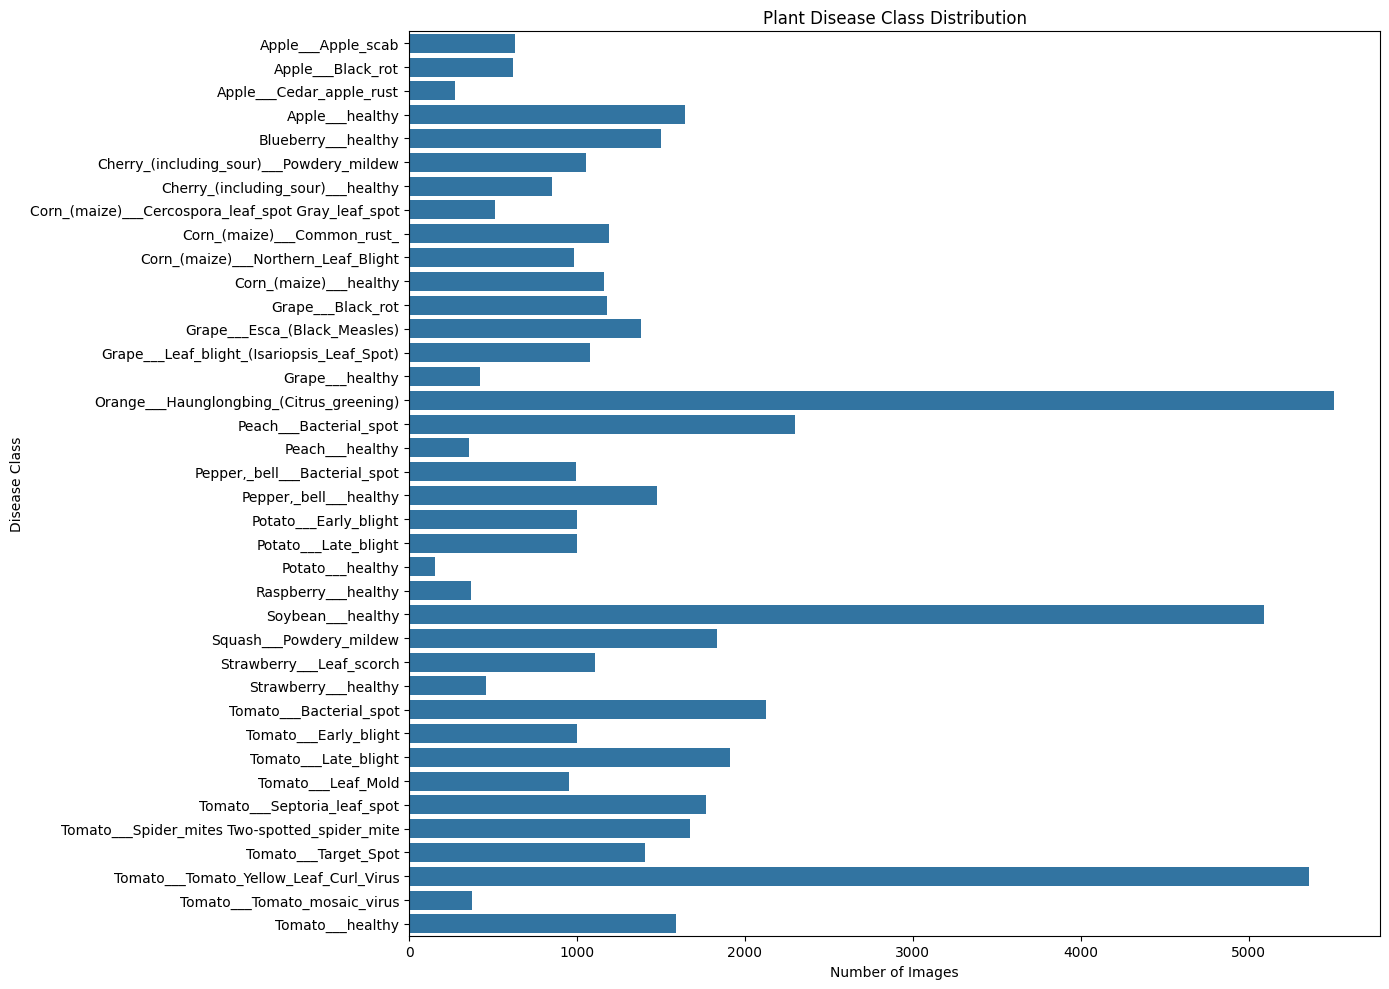

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))

sns.barplot(
    data=class_counts_df,
    x="Number of Images",
    y="Class"
)

plt.title("Plant Disease Class Distribution")
plt.xlabel("Number of Images")
plt.ylabel("Disease Class")

plt.tight_layout()
plt.show()

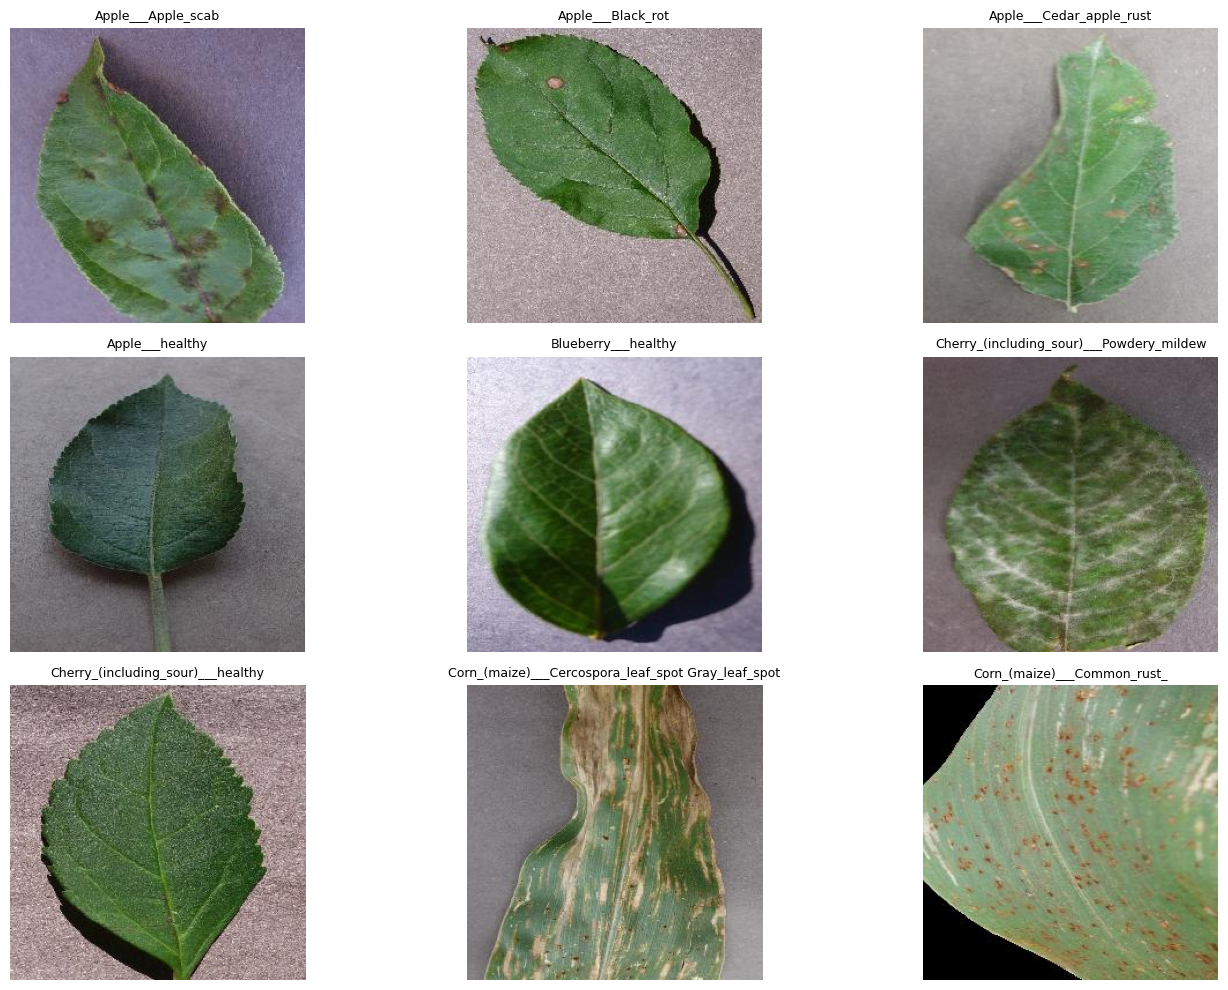

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

plt.figure(figsize=(15, 10))

for i, cls in enumerate(classes[:9]):

    class_path = os.path.join(color_path, cls)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    image_path = os.path.join(class_path, image_files[0])
    image = Image.open(image_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(cls, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image
import os

sample_class = classes[0]
sample_folder = os.path.join(color_path, sample_class)

image_files = [
    f for f in os.listdir(sample_folder)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

image_path = os.path.join(sample_folder, image_files[0])

image = Image.open(image_path)

print("Image Size:", image.size)
print("Image Mode:", image.mode)
print("Number of Channels:", len(image.getbands()))

Image Size: (256, 256)
Image Mode: RGB
Number of Channels: 3


Minimum Pixel Value: 6
Maximum Pixel Value: 212
Mean Pixel Value: 110.81


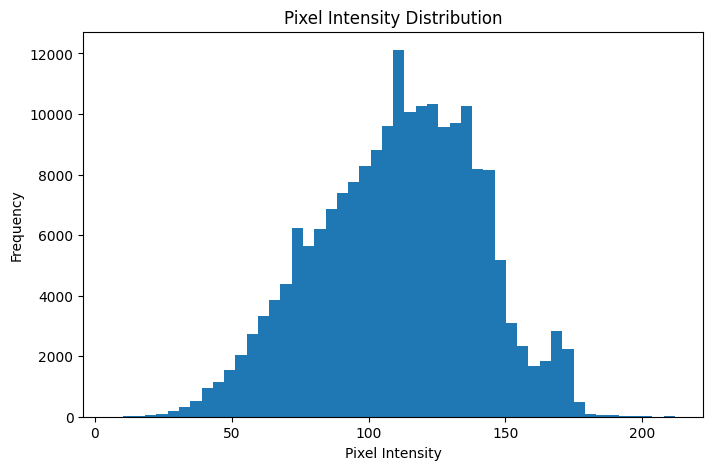

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

img_array = np.array(image)

print("Minimum Pixel Value:", img_array.min())
print("Maximum Pixel Value:", img_array.max())
print("Mean Pixel Value:", round(img_array.mean(), 2))

plt.figure(figsize=(8, 5))
plt.hist(img_array.ravel(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()